In [ ]:
import os
from pathlib import Path
# Resolve submission_partition_draft root from common launch locations.
def _resolve_partition_root():
    cwd = Path(os.getcwd()).resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "primary_script").exists() and (p / "intermediate").exists():
            return p
        candidate = p / "technical_review" / "submission_partition_draft"
        if (candidate / "primary_script").exists():
            return candidate
    raise RuntimeError("Could not locate submission_partition_draft root")
REPO_ROOT = _resolve_partition_root()


In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import scvi
import torch
import warnings
import leidenalg as la
import anndata
from scipy.io import mmwrite
from matplotlib import pyplot as plt
from matplotlib.pyplot import rc_context
from scvi.autotune import ModelTuner
from ray import tune

In [3]:
print('scanpy version:', sc.__version__)

scanpy version: 1.9.6


In [4]:
import pynndescent
print('pynndescent version:', pynndescent.__version__)

pynndescent version: 0.5.13


In [5]:
import umap
print('umap version:', umap.__version__)

umap version: 0.5.6


In [6]:
warnings.filterwarnings('ignore')
sc.set_figure_params(dpi=200)
plt.rcParams['figure.figsize'] = [3,3]

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [8]:
os.chdir(str(REPO_ROOT / 'intermediate'))

In [15]:
myeloid = sc.read_h5ad(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'pbmc_subset_myeloid.h5ad'))
adata = anndata.AnnData(X = myeloid.layers['counts'], obs = myeloid.obs, var = myeloid.raw.var)
sc.pp.filter_cells(adata, min_genes = 200)
sc.pp.filter_genes(adata, min_cells = 10)
adata.var['MT'] = adata.var_names.str.startswith('MT-')
adata = adata[adata.obs.percent_mito <= 10]
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum = 1e4)
sc.pp.log1p(adata)
adata.raw = adata
sc.pp.highly_variable_genes(adata, n_top_genes=5000, subset = False, layer = 'counts', 
                            flavor = "seurat_v3", batch_key="lane")
adata_var = adata.var
csv_data = pd.read_csv(str(REPO_ROOT / 'primary_dependents' / 'EXCLUDE_XY_TCR_IG.csv'), header = None)

positions = np.where(adata.var_names.isin(csv_data[0]))[0]
adata.var.iloc[positions, adata.var.columns.get_loc('highly_variable')] = False
adata.var['highly_variable'].value_counts()

highly_variable
False    15848
True      4737
Name: count, dtype: int64

In [16]:
model_cls = scvi.model.SCVI
model_cls.setup_anndata(adata = adata, layer = "counts", batch_key = 'lane', 
                        categorical_covariate_keys=['study_id'], 
                        continuous_covariate_keys=['percent_mito', 'nCount_RNA'])
tuner = ModelTuner(model_cls)
search_space = {
    "n_hidden": tune.choice([92, 128, 192, 256]),
    "n_latent": tune.choice([10, 20, 30, 40, 50, 60]),
    "n_layers": tune.choice([1, 2, 3]),
    "lr": tune.loguniform(1e-4, 1e-2),
    "gene_likelihood": tune.choice(["nb", "zinb"])}
results = tuner.fit(adata, metric="validation_loss",
                    resources = {'gpu': 1}, 
                    search_space = search_space,
                    num_samples = 100,
                    max_epochs = 20)

2024-09-06 02:02:37,085	INFO worker.py:1749 -- Started a local Ray instance.
2024-09-06 02:02:38,460	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `Tuner(...)`.
2024-09-06 02:02:38,464	INFO tune.py:614 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
(_trainable pid=2314445) /media/MPEdge16/miniconda_ns/lib/python3.9/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.
(_trainable pid=2314445) 
(_trainable pid=2314445) For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.
(_trainable pid=2314445) 
(_trainable pid=2314445) For creation, use `anndata.experimental.sparse_dataset(X)` ins

In [17]:
best_vl = 10000
best_i = 0
for i in range(len(results.results)):
    if 'validation_loss' in results.results[i].metrics.keys():
        vl = results.results[i].metrics['validation_loss']
        if vl < best_vl:
            best_vl = vl
            best_i = i
    else:
        continue
results.results[best_i]

Result(
  metrics={'validation_loss': 4336.4892578125},
  path='/media/MPEdge16/MM137/sc/py/scvi_log/autotune/2024-09-06_02-02-31_scvi/_trainable_a812efc0_7_gene_likelihood=nb,lr=0.0058,n_hidden=92,n_latent=60,n_layers=2_2024-09-06_02-09-35',
  filesystem='local',
  checkpoint=None
)

In [18]:
scvi.model.SCVI.setup_anndata(adata = adata, layer = "counts", batch_key = 'lane', 
                              categorical_covariate_keys=['study_id'], 
                              continuous_covariate_keys=['percent_mito', 'nCount_RNA'])
model = scvi.model.SCVI(adata, n_hidden = 92, n_latent = 60, n_layers = 2, gene_likelihood = 'nb')
kwargs = {'lr': 0.0058}
model.train(max_epochs = 200, early_stopping = True, plan_kwargs = kwargs)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX 4000 Ada Generation') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 200/200: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 200/200 [24:29<00:00,  7.50s/it, v_num=1, train_loss_step=4.3e+3, train_loss_epoch=4.35e+3]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 200/200 [24:29<00:00,  7.35s/it, v_num=1, train_loss_step=4.3e+3, train_loss_epoch=4.35e+3]


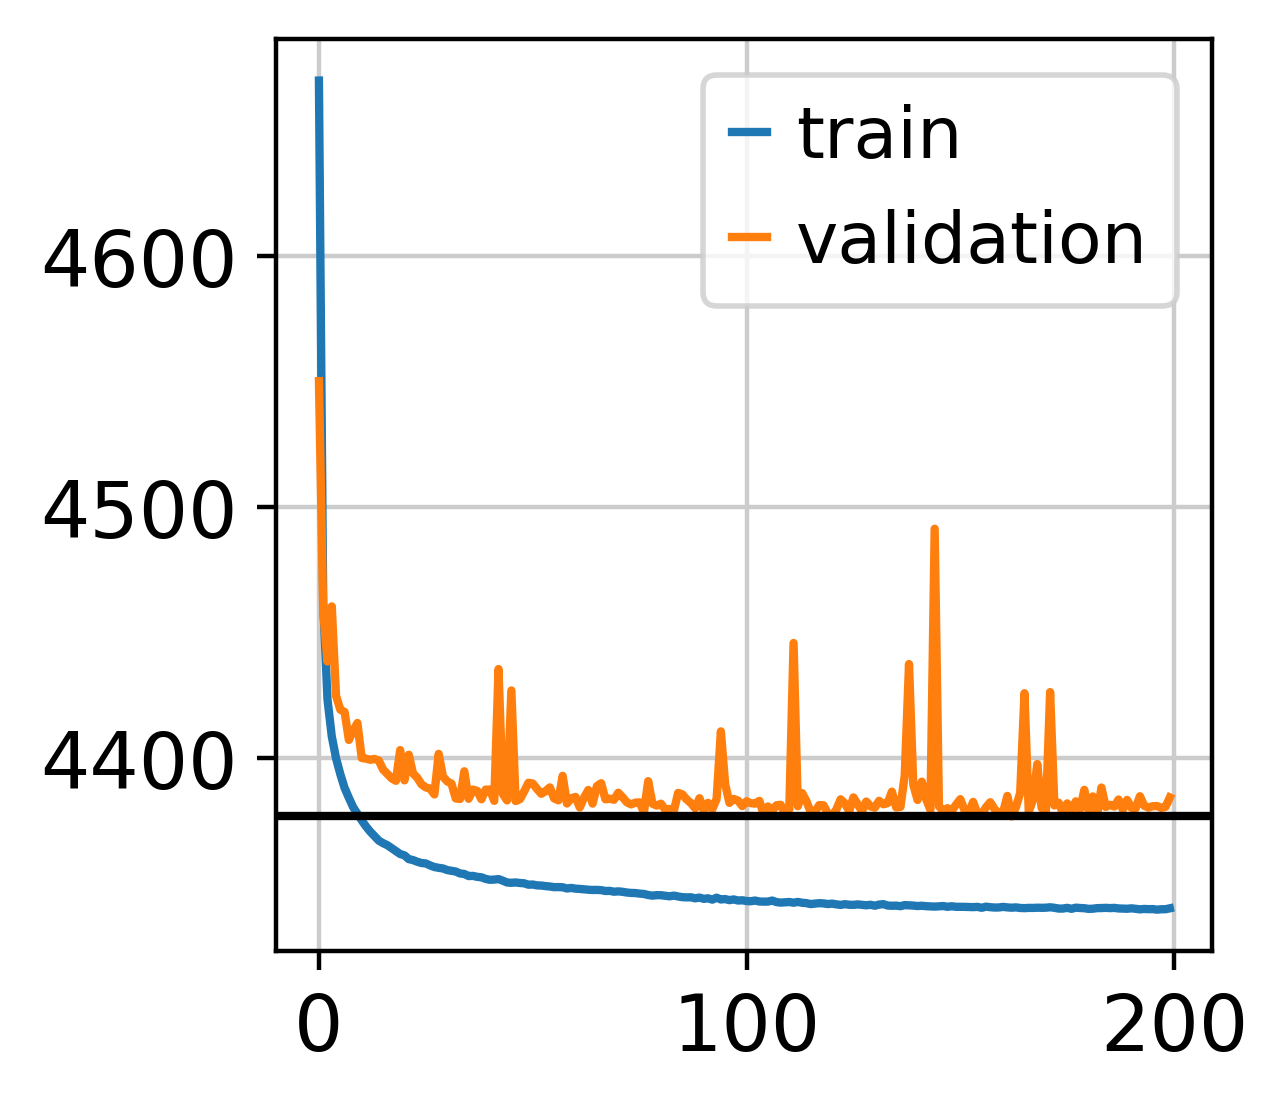

In [19]:
y = model.history['reconstruction_loss_validation']['reconstruction_loss_validation'].min()
plt.plot(model.history['reconstruction_loss_train']['reconstruction_loss_train'], label='train')
plt.plot(model.history['reconstruction_loss_validation']['reconstruction_loss_validation'], label='validation')

plt.axhline(y, c = 'k')

plt.legend()
plt.show()

In [9]:
adata = sc.read_h5ad(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'temp_pbmc_myeloid.h5ad'))
#model.save('pbmc/pbmc_myeloid_scvi_integration_model')
model = scvi.model.SCVI.load(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'pbmc_myeloid_scvi_integration_model/'), adata)
adata.write_h5ad(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'temp_pbmc_myeloid.h5ad'))

INFO     File /media/MPEdge16/MM137/sc/py/py_out/pbmc/pbmc_myeloid_scvi_integration_model/model.pt already         
         downloaded                                                                                                


In [10]:
adata.obsm['X_scVI'] = model.get_latent_representation()
scvi_norm_count = model.get_normalized_expression(library_size = 1e4)
adata.layers['scvi_normalized'] = scvi_norm_count

In [11]:
sc.pp.neighbors(adata, use_rep = 'X_scVI', random_state = 123)
sc.tl.umap(adata)

In [30]:
sc.tl.leiden(adata, resolution = 1, key_added = 'overcluster')

In [31]:
adata.write_h5ad(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'pbmc_myeloid_int.h5ad'))

In [ ]:
sc.pl.umap(adata, color = 'lane', size = 3, legend_fontsize = 'medium')

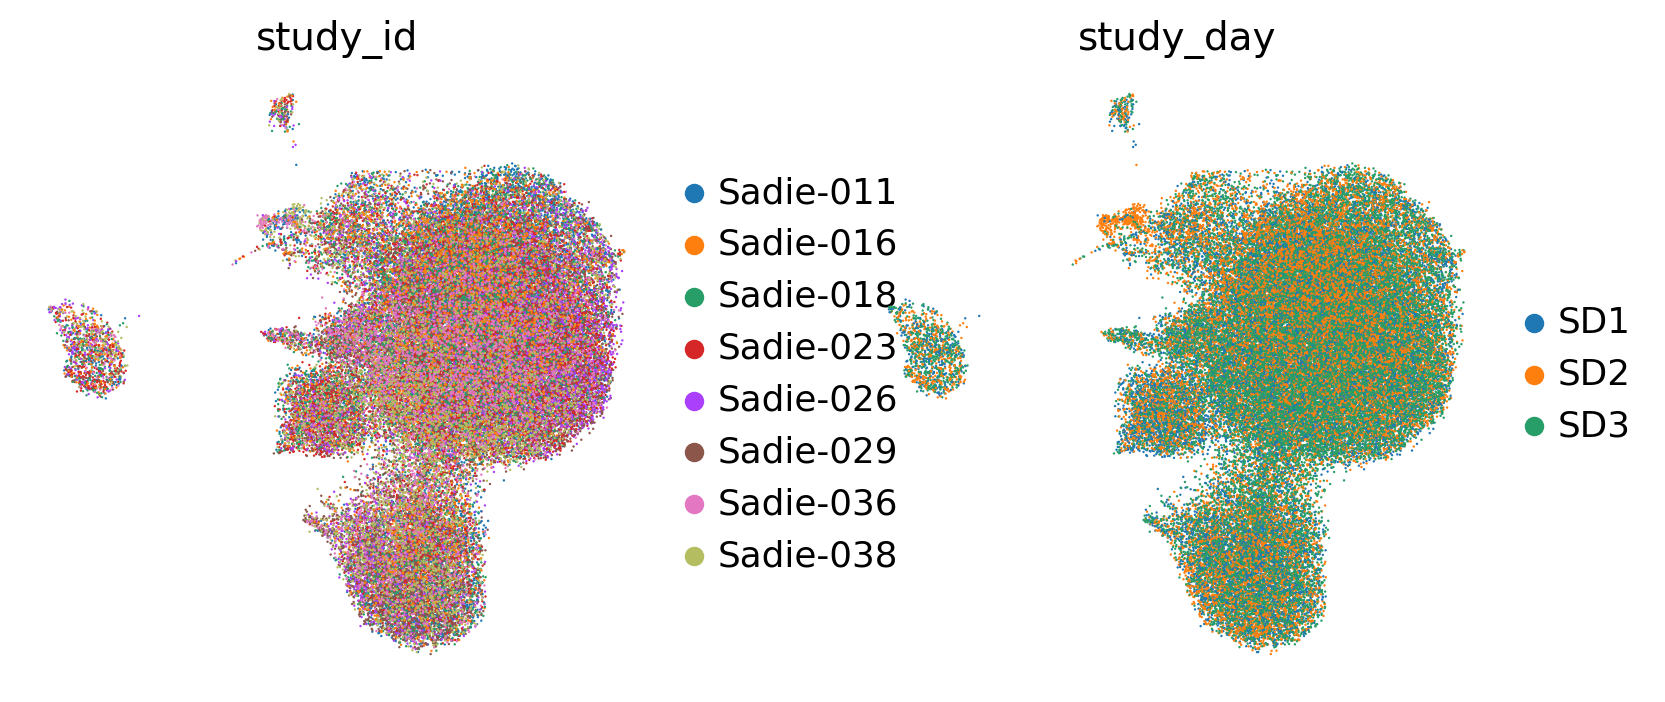

In [33]:
with rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(adata, color = ['study_id', 'study_day'], size = 3, frameon = False)

In [ ]:
sc.set_figure_params(dpi=200)

sc.pl.umap(adata, color = ['CD14','FCGR3A','LYZ','PLD4','ITM2C','S100A9','NEAT1','LILRA4','CLEC9A','HLA-DQA1','FCER1A','IRF4'], size = 4, frameon = False, layer = 'scvi_normalized')

In [ ]:
plt.rcParams['figure.figsize'] = [7, 7]
sc.pl.umap(adata, color = ['overcluster'], legend_loc = 'on data', size = 3, layer = 'scvi_normalized', legend_fontsize = 'x-small')

In [ ]:
sc.set_figure_params(dpi=100)
sc.pl.dotplot(adata, ['CD14','FCGR3A','LYZ','PLD4','ITM2C','S100A9','NEAT1','LILRA4','CLEC9A','IDO1','HLA-DQA1','FCER1A','CLEC10A','IRF4','MKI67','GNG11','PPBP','PF4','CAVIN2','TUBB1'], groupby = 'overcluster', swap_axes = True,
              use_raw = True, standard_scale = 'var', dendrogram = False)

In [ ]:
asdc = ['PPP1R14A', 'LILRA4', 'AXL', 'IL3RA', 'SCT', 'SCN9A', 'LGMN', 'DNASE1L3', 'CLEC4C', 'GAS6']
cdc1 = ['CLEC9A', 'DNASE1L3', 'C1orf54', 'IDO1', 'CLNK', 'CADM1', 'FLT3', 'ENPP1', 'XCR1', 'NDRG2']
cdc2 = ['FCER1A', 'HLA-DQA1', 'CLEC10A', 'CD1C', 'ENHO', 'PLD4', 'GSN', 'SLC38A1', 'NDRG2', 'AFF3']
pdc = ['ITM2C', 'PLD4', 'SERPINF1', 'LILRA4', 'IL3RA', 'TPM2', 'MZB1', 'SPIB', 'IRF4', 'SMPD3']

sc.set_figure_params(dpi=100)
sc.pl.dotplot(adata, {'ASDC': asdc, 'cDC1': cdc1, 'cDC2': cdc2, 'pDC': pdc, 'm8': ['CCL19','LAMP3']}, groupby = 'overcluster', swap_axes = True,
              use_raw = True, standard_scale = 'var', dendrogram = False)

In [40]:
#uclus = max(adata.obs['overcluster'].astype(int))
#for i in range(uclus+1):
#    print("'" + str(i) + "'" + ": " + "'" + "',")

In [15]:
myeloid_types = {
    '0': 'CD16 Mono',
    '1': 'CD14 Mono',
    '2': 'CD14 Mono',
    '3': 'CD14 Mono',
    '4': 'CD14 Mono',
    '5': 'CD14 Mono',
    '6': 'CD14 Mono',
    '7': 'M-platelet',
    '8': 'CD14 Mono', # CCL19, LAMP3 look interesting here but non-zero % express is < 1%
    '9': 'cDC2',
    '10': 'CD14 Mono',
    '11': 'CD14 Mono',
    '12': 'CD14 Mono',
    '13': 'CD14 Mono',
    '14': 'pDC',
    '15': 'cDC1'
}

In [ ]:
adata.obs['merged_type'] = adata.obs['overcluster'].map(myeloid_types)

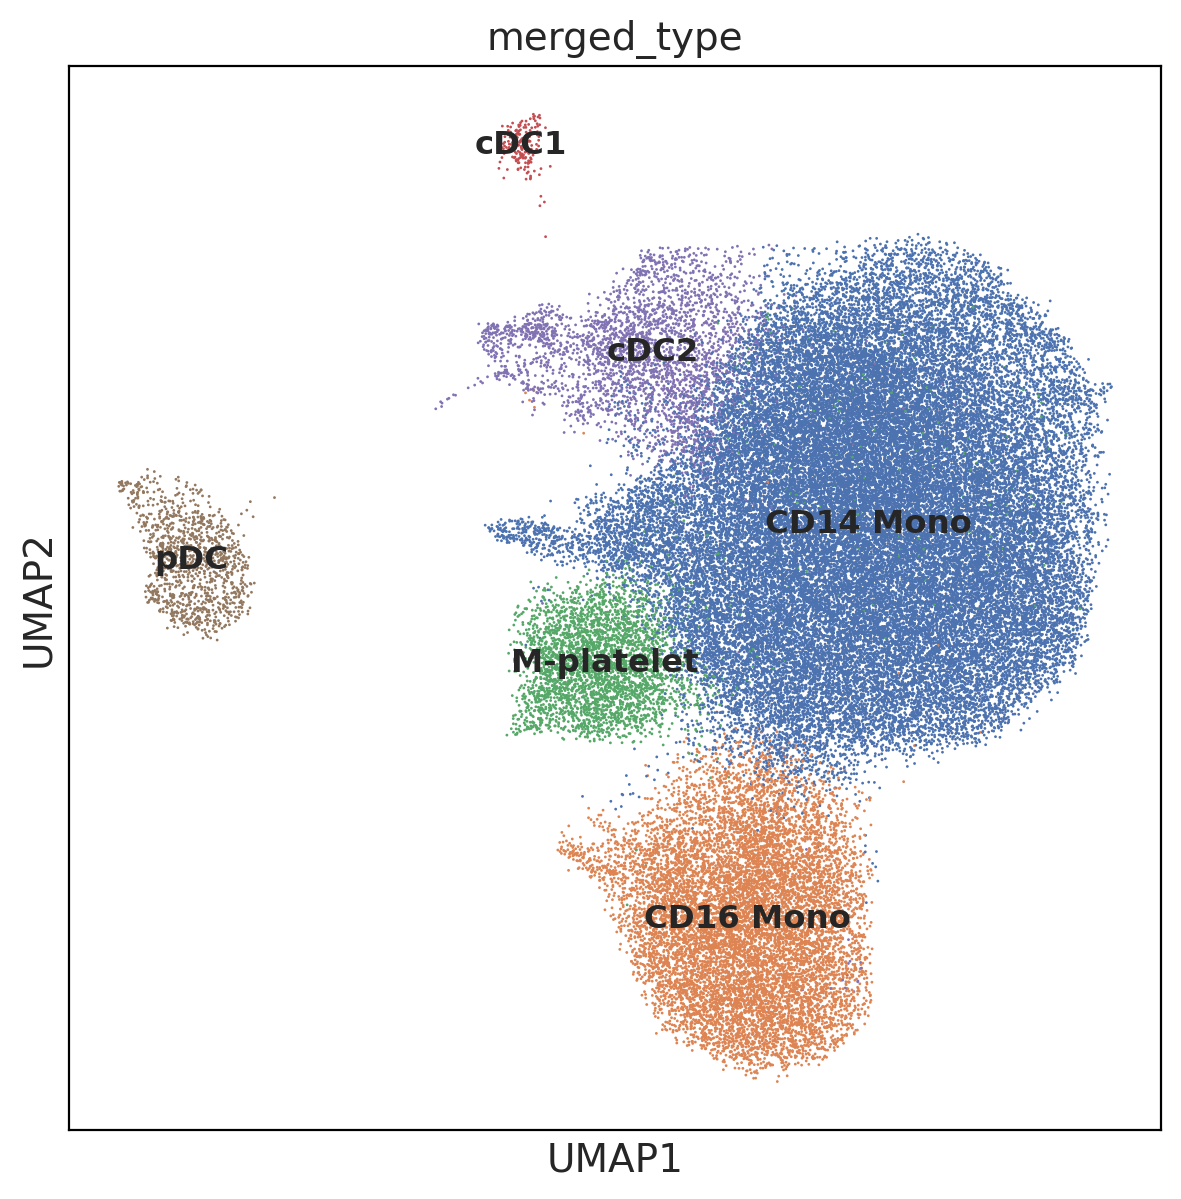

In [34]:
plt.rcParams['figure.figsize'] = [7, 7]
sc.pl.umap(adata, color = ['merged_type'], legend_loc = 'on data', size = 4, layer = 'scvi_normalized', legend_fontsize = 'small')

In [ ]:
adata.write_h5ad(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'pbmc_myeloid.h5ad'))

In [ ]:
# used to annotate the myeloid clusters in the integrated umap with the overcluster and merged_type info
adata.obs[['barcode_2','overcluster','merged_type']].to_csv(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'pbmc_myeloid_cell_map.csv'), index = False)

In [12]:
latent_coord = adata.obsm['X_scVI']
umap_coord = adata.obsm['X_umap']
rna_counts = adata.layers['counts'] # whole integer counts, no normalization
adata_obs = adata.obs
adata_var = adata.var

In [15]:
mmwrite(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'anndata_elements/adata_pbmc_myeloid_counts.mtx'), rna_counts)
adata_obs.to_csv(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'anndata_elements/adata_pbmc_myeloid_obs.csv'))
adata_var.to_csv(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'anndata_elements/adata_pbmc_myeloid_var.csv'))

In [16]:
np.savetxt(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'anndata_elements/adata_pbmc_myeloid_latent_coordinates.csv'), latent_coord, delimiter = ',')
np.savetxt(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'anndata_elements/adata_pbmc_myeloid_umap_coordinates.csv'), umap_coord, delimiter = ',')